# Comparative Study of Deep Learning Models for Facial Landmark Detection in Plastic Surgery Analysis

Kelompok 6

---

### Data Preprocessing

Import Libraries

In [ ]:
!pip install Optuna

In [ ]:
import os
import cv2
import zipfile
from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from sklearn.model_selection import train_test_split

import math
import gc
import optuna

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

Data Reading

In [ ]:
drive.mount('/content/drive')
zip_path = "/content/drive/MyDrive/ibug_300W_large_face_landmark_dataset.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall("/content/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_PATH = "ibug_300W_large_face_landmark_dataset"
XML_FILE = os.path.join(DATASET_PATH, "labels_ibug_300W.xml")

TARGET_SIZE = 256
BATCH_SIZE = 16
NUM_EPOCHS = 20
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
print(os.path.exists(XML_FILE))

True


In [ ]:
#Read metadata
tree = ET.parse(XML_FILE)
root = tree.getroot()

data = []

for image_tag in root.iter("image"):
    image_file = image_tag.get("file")
    image_path = os.path.join(DATASET_PATH, image_file)
    if not os.path.exists(image_path):
        continue
    box = image_tag.find("box")
    top = int(box.get("top"))
    left = int(box.get("left"))
    width = int(box.get("width"))
    height = int(box.get("height"))

    if width <= 0 or height <= 0:
        continue

    landmarks = []
    for part in box.iter("part"):
        landmark_id = int(part.get("name"))
        x = int(part.get("x"))
        y = int(part.get("y"))
        landmarks.append((x, y))

    if len(landmarks) != 68:
        continue

    landmarks = np.array(landmarks, dtype=np.float32)

    datas = {
        "image_path": image_path,
        "bbox": (left, top, width, height),
        "landmarks": landmarks
    }
    data.append(datas)

print("Total Images:", len(data))

Total Images: 7674


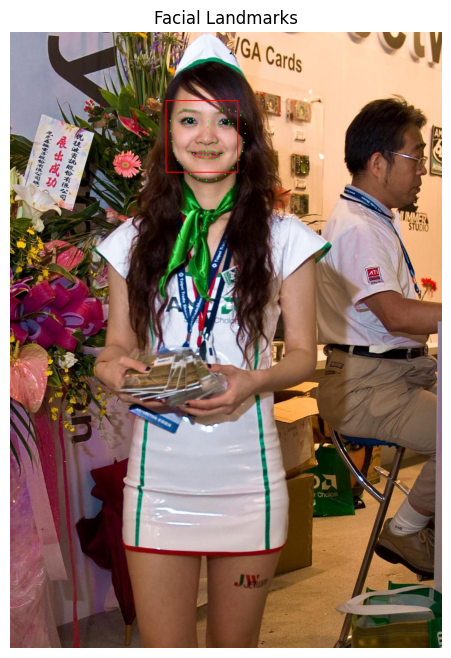

In [ ]:
#Testing landmarks
sample = data[0]
image = cv2.imread(sample["image_path"])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
landmarks = sample["landmarks"].astype(int)

for (x, y) in landmarks:
    cv2.circle(image,(x, y),2,(0, 255, 0),-1)

left, top, width, height = sample["bbox"]
cv2.rectangle(
    image,
    (int(left), int(top)),
    (int(left + width), int(top + height)),
    (255, 0, 0),
    2
)

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title("Facial Landmarks")
plt.axis("off")
plt.show()

In [ ]:
#Checking if any images are missing during reading
missing = 0
for sample in data:
    image = cv2.imread(sample["image_path"])
    if image is None:
        missing += 1
        print("Missing:", sample["image_path"])

print("Total Missing:", missing)

Total Missing: 0


In [ ]:
#Cropping the face to center the face and to remove background noise
sample = data[0]
image = cv2.imread(sample["image_path"])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
left, top, width, height = sample["bbox"]

#Add padding to the face:
padding = 0.2

pad_x = int(width * padding)
pad_y = int(height * padding)

new_left = max(0, left - pad_x)
new_top = max(0, top - pad_y)

new_right = min(image.shape[1],left + width + pad_x)

new_bottom = min(image.shape[0],top + height + pad_y)

face = image[new_top:new_bottom,new_left:new_right]

Data Splitting

In [ ]:
train_data, temp_data = train_test_split(data, test_size=0.3, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 5371
Validation: 1151
Test: 1152


Data Augmentation

In [ ]:
#Data augmentation to prevent overfitting
#Training augmentation
train_transform = A.Compose([
    #Changes lighting so the model works in any brightness.
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    #Shifts colors so the model ignores skin tone differences.
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.4),
    A.GaussianBlur(blur_limit=(3,5), p=0.2),
    #Removes color to force focus on facial structure.
    A.ToGray(p=0.1),
    A.Resize(TARGET_SIZE, TARGET_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

val_transform = A.Compose([
    A.Resize(TARGET_SIZE, TARGET_SIZE),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
], keypoint_params=A.KeypointParams(
    format='xy',
    remove_invisible=False
))

In [ ]:
class FacialLandmarkDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = cv2.imread(sample["image_path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        left, top, width, height = sample["bbox"]

        # Padding
        padding = 0.2

        pad_x = int(width * padding)
        pad_y = int(height * padding)

        new_left = max(0, left - pad_x)
        new_top = max(0, top - pad_y)

        new_right = min(image.shape[1], left + width + pad_x)
        new_bottom = min(image.shape[0], top + height + pad_y)

        # Crop face
        face = image[new_top:new_bottom, new_left:new_right]

        # Empty crop protection
        if face.size == 0:
            face = np.zeros((TARGET_SIZE, TARGET_SIZE, 3), dtype=np.uint8)

        landmarks = sample["landmarks"].copy().astype(np.float32)

        # Shift landmarks after crop
        landmarks[:, 0] -= new_left
        landmarks[:, 1] -= new_top

        transformed = self.transform(
            image=face,
            keypoints=landmarks.tolist()
        )

        # print(f"Type: {type(transformed['keypoints'])}")
        # print(f"Length: {len(transformed['keypoints'])}")
        # print(f"Sample Points: {transformed['keypoints'][:5]}")

        image = transformed["image"]
        landmarks = np.array(transformed["keypoints"], dtype=np.float32)

        # print(f"Shape setelah jadi Numpy: {landmarks.shape}")

        # Landmark normalization
        landmarks[:, 0] /= TARGET_SIZE
        landmarks[:, 1] /= TARGET_SIZE

        landmarks = landmarks.flatten()

        return image, torch.tensor(landmarks, dtype=torch.float32)

DataLoader

In [ ]:
train_dataset = FacialLandmarkDataset(train_data, transform=train_transform)
val_dataset = FacialLandmarkDataset(val_data, transform=val_transform)
test_dataset = FacialLandmarkDataset(test_data, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
img, lbl = test_dataset[0]

Visual Landmark Alignment Check

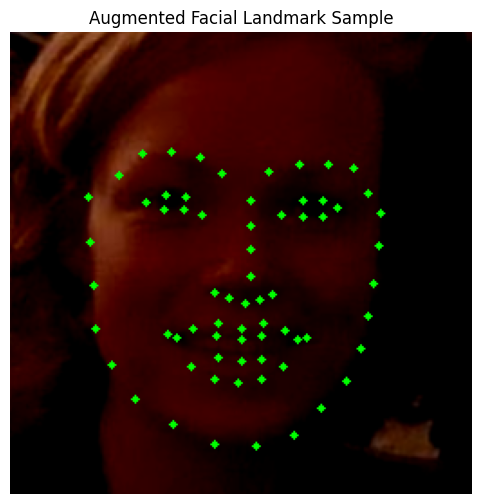

In [ ]:
# Get one sample
image, landmarks = train_dataset[42]

# Convert tensor image -> numpy
display_image = image.permute(1, 2, 0).numpy()

# Denormalize image
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

display_image = (display_image * std) + mean
display_image = np.clip(display_image, 0, 1)

# Reshape landmarks
landmarks = landmarks.numpy().reshape(68, 2)

# Convert normalized landmarks back to pixel coordinates
display_landmarks = landmarks.copy()

display_landmarks[:, 0] *= TARGET_SIZE
display_landmarks[:, 1] *= TARGET_SIZE

# Draw landmarks
display_image_cv = (display_image * 255).astype(np.uint8).copy()

for (x, y) in display_landmarks.astype(int):
    cv2.circle(
        display_image_cv,
        (x, y),
        2,
        (0, 255, 0),
        -1
    )

# Show image
plt.figure(figsize=(6,6))
plt.imshow(display_image_cv)
plt.axis("off")
plt.title("Augmented Facial Landmark Sample")
plt.show()

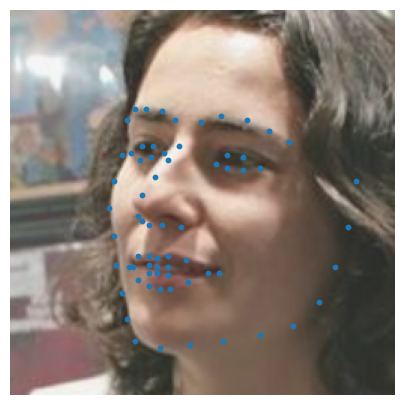

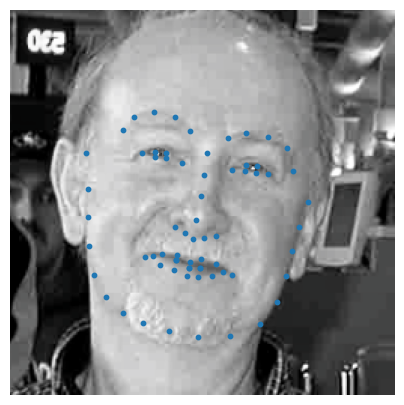

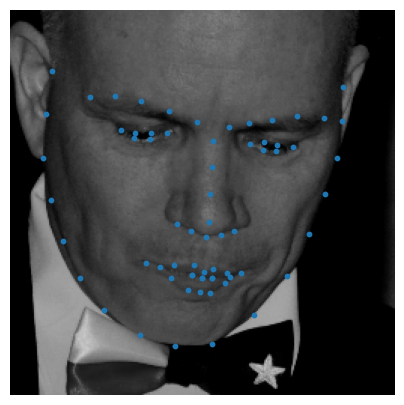

In [ ]:
for i in range(3):

    image, landmarks = train_dataset[i]

    display_image = image.permute(1, 2, 0).numpy()
    display_image = (display_image * std) + mean
    display_image = np.clip(display_image, 0, 1)

    landmarks = landmarks.numpy().reshape(68, 2)

    display_landmarks = landmarks.copy()

    display_landmarks[:, 0] *= TARGET_SIZE
    display_landmarks[:, 1] *= TARGET_SIZE


    plt.figure(figsize=(5,5))
    plt.imshow(display_image)

    plt.scatter(
        display_landmarks[:,0],
        display_landmarks[:,1],
        s=10
    )

    plt.axis("off")
    plt.show()

### Modelling & Training

Baseline Model ResNet18 + MSE

In [ ]:
class ResNetBaseline(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )

        # Freeze backbone first
        for param in self.model.parameters():
            param.requires_grad = False

        # Unfreeze layer4
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        # Replace FC layer
        self.model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(
                self.model.fc.in_features,
                136
            )
        )

    def forward(self, x):
        return self.model(x)

PFLD Model

In [ ]:
class PFLD(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(512, 136)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.regressor(x)

        return x

HRNet Model

In [ ]:
class HRNetLike(nn.Module):
    def __init__(self):
        super().__init__()
        self.stage1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.stage2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.stage3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 136)
        )

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x)
        x = self.regressor(x)

        return x

NME Metric

In [ ]:
def calculate_nme(preds, targets):
    if isinstance(preds, np.ndarray):
        preds = torch.tensor(preds)
    if isinstance(targets, np.ndarray):
        targets = torch.tensor(targets)

    preds = preds.reshape(-1, 68, 2)
    targets = targets.reshape(-1, 68, 2)
    preds = preds * TARGET_SIZE
    targets = targets * TARGET_SIZE

    left_eye = targets[:, 36]
    right_eye = targets[:, 45]
    interocular_distance = torch.norm(
        left_eye - right_eye,
        dim=1
    )
    # Landmark distances
    distances = torch.norm(
        preds - targets,
        dim=2
    )

    mean_distance = distances.mean(dim=1)
    nme = mean_distance / interocular_distance

    return nme.mean().item()

Training Function

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    model_name,
    learning_rate=LEARNING_RATE,
    optimizer_name="Adam",
    weight_decay=0.0,
    num_epochs=NUM_EPOCHS,
    save_path=None
):

    model = model.to(DEVICE)

    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "AdamW":

        optimizer = optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    else:

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=3,
        factor=0.5
    )

    train_losses = []
    val_losses = []
    nme_scores = []

    best_val_loss = float("inf")

    if save_path is None:
        save_path = f"best_{model_name}.pth"

    history_path = f"{model_name}_history.pth"

    # =========================
    # TRAINING LOOP
    # =========================
    for epoch in range(num_epochs):

        # =========================
        # TRAIN
        # =========================
        model.train()

        running_train_loss = 0.0

        train_bar = tqdm(
            train_loader,
            desc=f"{model_name} Epoch {epoch+1}/{num_epochs}"
        )

        for images, landmarks in train_bar:

            images = images.to(DEVICE)
            landmarks = landmarks.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                landmarks
            )

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

            train_bar.set_postfix(
                loss=f"{loss.item():.6f}"
            )

        train_loss = running_train_loss / len(train_loader)

        # =========================
        # VALIDATION
        # =========================
        model.eval()

        running_val_loss = 0.0

        all_preds = []
        all_targets = []

        with torch.no_grad():

            for images, landmarks in val_loader:

                images = images.to(DEVICE)
                landmarks = landmarks.to(DEVICE)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    landmarks
                )

                running_val_loss += loss.item()

                all_preds.append(
                    outputs.cpu().numpy()
                )

                all_targets.append(
                    landmarks.cpu().numpy()
                )

        val_loss = running_val_loss / len(val_loader)

        # =========================
        # CALCULATE NME
        # =========================
        all_preds = np.concatenate(
            all_preds,
            axis=0
        )
        all_targets = np.concatenate(
            all_targets,
            axis=0
        )
        nme = calculate_nme(
            all_preds,
            all_targets
        )
        scheduler.step(val_loss)


        train_losses.append(train_loss)
        val_losses.append(val_loss)
        nme_scores.append(nme)
        print(
            f"\nEpoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"NME: {nme:.4f} ({nme*100:.2f}%)"
        )
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            history = {
                "train_loss": train_losses,
                "val_loss": val_losses,
                "nme": nme_scores
            }
            torch.save(history, history_path)
            print(f"Best model saved: {save_path}")
            print(f"History saved: {history_path}")
    torch.cuda.empty_cache()
    gc.collect()
    return train_losses, val_losses, nme_scores

Train Baseline Model (ResNet)

In [ ]:
criterion_smooth = nn.SmoothL1Loss()
resnet_model = ResNetBaseline()

# if os.path.exists("best_resnet_baseline.pth"):
#     resnet_model.load_state_dict(torch.load("best_resnet_baseline.pth", map_location=DEVICE))
#     history = torch.load("resnet_baseline_history.pth")
#     resnet_train_loss = history["train_loss"]
#     resnet_val_loss = history["val_loss"]
#     resnet_nme = history["nme"]
#     print("Loaded saved ResNet baseline model")
# else:
#     resnet_train_loss, resnet_val_loss, resnet_nme = train_model(
#         model=resnet_model,
#         train_loader=train_loader,
#         val_loader=val_loader,
#         criterion=criterion_smooth,
#         model_name="resnet_baseline",
#         learning_rate=LEARNING_RATE,
#         optimizer_name="Adam",
#         num_epochs=NUM_EPOCHS,
#         save_path="best_resnet_baseline.pth"
#     )
#     print("ResNet baseline trained and saved!")

Train PFLD

In [ ]:
class WingLoss(nn.Module):
    def __init__(self, w=0.05, epsilon=0.01):
        super().__init__()
        self.w = w
        self.epsilon = epsilon
        self.C = w - w * math.log(1 + w / epsilon)

    def forward(self, predictions, targets):
        x = torch.abs(predictions - targets)
        loss = torch.where(
            x < self.w,
            self.w * torch.log(1 + x / self.epsilon),
            x - self.C
        )
        return loss.mean()

In [ ]:
criterion_wing = WingLoss(w=0.05, epsilon=0.01)
pfld_model = PFLD()

# if os.path.exists("best_pfld.pth"):
#     pfld_model.load_state_dict(torch.load("best_pfld.pth", map_location=DEVICE))
#     history = torch.load("pfld_history.pth")
#     pfld_train_loss = history["train_loss"]
#     pfld_val_loss = history["val_loss"]
#     pfld_nme = history["nme"]
#     print("Loaded saved PFLD baseline model")
# else:
#     pfld_train_loss, pfld_val_loss, pfld_nme = train_model(
#         model=pfld_model,
#         train_loader=train_loader,
#         val_loader=val_loader,
#         criterion=criterion_wing,
#         model_name="pfld",
#         learning_rate=LEARNING_RATE,
#         optimizer_name="Adam",
#         num_epochs=NUM_EPOCHS,
#         save_path="best_pfld.pth"
#     )
#     print("PFLD baseline trained and saved!")

Train HRNet

In [ ]:
criterion_mse = nn.MSELoss()
hrnet_model = HRNetLike()

# if os.path.exists("best_hrnet.pth"):
#     hrnet_model.load_state_dict(torch.load("best_hrnet.pth", map_location=DEVICE))
#     history = torch.load("hrnet_history.pth")
#     hrnet_train_loss = history["train_loss"]
#     hrnet_val_loss = history["val_loss"]
#     hrnet_nme = history["nme"]
#     print("Loaded saved HRNet baseline model")
# else:
#     hrnet_train_loss, hrnet_val_loss, hrnet_nme = train_model(
#         model=hrnet_model,
#         train_loader=train_loader,
#         val_loader=val_loader,
#         criterion=criterion_mse,
#         model_name="hrnet",
#         learning_rate=LEARNING_RATE,
#         optimizer_name="Adam",
#         num_epochs=NUM_EPOCHS,
#         save_path="best_hrnet.pth"
#     )
#     print("HRNet baseline trained and saved!")

Visualization Loss

In [ ]:
def plot_losses(train_losses, val_losses, title):
    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# plot_losses(resnet_train_loss, resnet_val_loss, "ResNet Baseline Loss Curve")
# plot_losses(pfld_train_loss, pfld_val_loss, "PFLD Loss Curve")
# plot_losses(hrnet_train_loss, hrnet_val_loss, "HRNet Loss Curve")

Hyperparameter Tuning

In [ ]:
def objective(trial, model_class, criterion):
    # HYPERPARAMETERS
    lr = trial.suggest_float(
        "lr",
        1e-4,
        1e-3,
        log=True
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "AdamW", "RMSprop"]
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-4,
        log=True
    )

    # MODEL
    model = model_class().to(DEVICE)

    # OPTIMIZER
    if optimizer_name == "Adam":
        optimizer = optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    else:
        optimizer = optim.RMSprop(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    # LEARNING RATE SCHEDULER
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=1
    )

    # SHORT TUNING TRAINING
    TUNING_EPOCHS = 3
    best_val_loss = float("inf")

    for epoch in range(TUNING_EPOCHS):

        # TRAIN
        model.train()
        running_train_loss = 0.0

        train_bar = tqdm(
            train_loader,
            desc=f"Trial {trial.number} Epoch {epoch+1}/{TUNING_EPOCHS}"
        )

        for images, landmarks in train_bar:
            images = images.to(DEVICE)
            landmarks = landmarks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(
                outputs,
                landmarks
            )
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
            train_bar.set_postfix(
                loss=f"{loss.item():.6f}"
            )

        train_loss = running_train_loss / len(train_loader)

        # VALIDATION
        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for images, landmarks in val_loader:
                images = images.to(DEVICE)
                landmarks = landmarks.to(DEVICE)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    landmarks
                )

                running_val_loss += loss.item()

        val_loss = running_val_loss / len(val_loader)

        # SAVE BEST LOSS
        if val_loss < best_val_loss:
            best_val_loss = val_loss

        scheduler.step(val_loss)

        # Report to Optuna
        trial.report(val_loss, epoch)

        # Pruning
        if trial.should_prune():
            del model
            torch.cuda.empty_cache()
            gc.collect()
            raise optuna.exceptions.TrialPruned()

        print(f"\nEpoch [{epoch+1}/{TUNING_EPOCHS}]")
        print(f"Train Loss: {train_loss:.6f}")
        print(f"Val Loss: {val_loss:.6f}")

    del model
    torch.cuda.empty_cache()
    gc.collect()

    return best_val_loss

Tuning ResNet

study_resnet = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=2,
        n_warmup_steps=2
    )
)

study_resnet.optimize(
    lambda trial: objective(
        trial,
        ResNetBaseline,
        criterion_smooth,
    ),
    n_trials=5
)

print("\n========== BEST RESNET PARAMS ==========")
print(f"Best Validation Loss: {study_resnet.best_value:.6f}")
for key, value in study_resnet.best_params.items():
    print(f"{key}: {value}")

Tuning PFLD

study_pfld = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=2,
        n_warmup_steps=2
    )
)

study_pfld.optimize(
    lambda trial: objective(
        trial,
        PFLD,
        criterion_wing,
    ),
    n_trials=5
)

print("\n========== BEST PFLD PARAMS ==========")
print(f"Best Validation Loss: {study_pfld.best_value:.6f}")
for key, value in study_pfld.best_params.items():
    print(f"{key}: {value}")

Tuning HRNet

study_hrnet = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=2,
        n_warmup_steps=2
    )
)

study_hrnet.optimize(
    lambda trial: objective(
        trial,
        HRNetLike,
        criterion_mse,
    ),
    n_trials=5
)

print("\n========== BEST HRNET PARAMS ==========")
print(f"Best Validation Loss: {study_hrnet.best_value:.6f}")
for key, value in study_hrnet.best_params.items():
    print(f"{key}: {value}")

Final Model Training

In [ ]:
resnet_tuned_model = ResNetBaseline()
resnet_tuned_train_loss = []
resnet_tuned_val_loss = []
resnet_tuned_nme = []

if os.path.exists("best_resnet_tuned.pth"):
    resnet_tuned_model.load_state_dict(torch.load("best_resnet_tuned.pth", map_location=DEVICE))
    if os.path.exists("resnet_tuned_history.pth"):
        history = torch.load("resnet_tuned_history.pth")
        resnet_tuned_train_loss = history["train_loss"]
        resnet_tuned_val_loss = history["val_loss"]
        resnet_tuned_nme = history["nme"]
        print("Loaded saved tuned ResNet model and history.")
    else:
        print("Loaded saved tuned ResNet model, but history file not found. Loss plots will be empty.")
else:
    if 'best_params' not in locals():
        print("Warning: 'best_params' not found. Using default LEARNING_RATE, Adam optimizer, and no weight decay for tuning.")
        best_params = {'lr': LEARNING_RATE, 'optimizer': 'Adam', 'weight_decay': 0.0}

    print("Tuned ResNet model not found. Starting training...")
    resnet_tuned_train_loss, resnet_tuned_val_loss, resnet_tuned_nme = train_model(
        model=resnet_tuned_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_smooth,
        model_name="resnet_tuned",
        learning_rate=best_params["lr"],
        optimizer_name=best_params["optimizer"],
        weight_decay=best_params["weight_decay"],
        num_epochs=NUM_EPOCHS,
        save_path="best_resnet_tuned.pth"
    )
    print("Tuned ResNet trained and saved!")

Loaded saved tuned ResNet model and history.


In [ ]:
pfld_tuned_model = PFLD()
pfld_tuned_train_loss = []
pfld_tuned_val_loss = []
pfld_tuned_nme = []

if os.path.exists("best_pfld_tuned.pth"):
    pfld_tuned_model.load_state_dict(torch.load("best_pfld_tuned.pth", map_location=DEVICE))
    if os.path.exists("pfld_tuned_history.pth"):
        history = torch.load("pfld_tuned_history.pth")
        pfld_tuned_train_loss = history["train_loss"]
        pfld_tuned_val_loss = history["val_loss"]
        pfld_tuned_nme = history["nme"]
        print("Loaded saved tuned PFLD model and history.")
    else:
        print("Loaded saved tuned PFLD model, but history file not found. Loss plots will be empty.")
else:
    if 'best_params' not in locals():
        print("Warning: 'best_params' not found. Using default LEARNING_RATE, Adam optimizer, and no weight decay for tuning.")
        best_params = {'lr': LEARNING_RATE, 'optimizer': 'Adam', 'weight_decay': 0.0}

    print("Tuned PFLD model not found. Starting training...")
    pfld_tuned_train_loss, pfld_tuned_val_loss, pfld_tuned_nme = train_model(
        model=pfld_tuned_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_wing,
        model_name="pfld_tuned",
        learning_rate=best_params["lr"],
        optimizer_name=best_params["optimizer"],
        weight_decay=best_params["weight_decay"],
        num_epochs=NUM_EPOCHS,
        save_path="best_pfld_tuned.pth"
    )
    print("Tuned PFLD trained and saved!")

Loaded saved tuned PFLD model and history.


In [ ]:
hrnet_tuned_model = HRNetLike()
hrnet_tuned_train_loss = []
hrnet_tuned_val_loss = []
hrnet_tuned_nme = []

if os.path.exists("best_hrnet_tuned.pth"):
    hrnet_tuned_model.load_state_dict(torch.load("best_hrnet_tuned.pth", map_location=DEVICE))
    if os.path.exists("hrnet_tuned_history.pth"):
        history = torch.load("hrnet_tuned_history.pth")
        hrnet_tuned_train_loss = history["train_loss"]
        hrnet_tuned_val_loss = history["val_loss"]
        hrnet_tuned_nme = history["nme"]
        print("Loaded saved tuned HRNet model and history.")
    else:
        print("Loaded saved tuned HRNet model, but history file not found. Loss plots will be empty.")
else:
    if 'best_params' not in locals():
        print("Warning: 'best_params' not found. Using default LEARNING_RATE, Adam optimizer, and no weight decay for tuning.")
        best_params = {'lr': LEARNING_RATE, 'optimizer': 'Adam', 'weight_decay': 0.0}

    print("Tuned HRNet model not found. Starting training...")
    hrnet_tuned_train_loss, hrnet_tuned_val_loss, hrnet_tuned_nme = train_model(
        model=hrnet_tuned_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_mse,
        model_name="hrnet_tuned",
        learning_rate=best_params["lr"],
        optimizer_name=best_params["optimizer"],
        weight_decay=best_params["weight_decay"],
        num_epochs=NUM_EPOCHS,
        save_path="best_hrnet_tuned.pth"
    )
    print("Tuned HRNet trained and saved!")

Loaded saved tuned HRNet model and history.


### Verify Model and History Files

In [ ]:
import os

model_files = [
    "best_resnet_tuned.pth",
    "resnet_tuned_history.pth",
    "best_pfld_tuned.pth",
    "pfld_tuned_history.pth",
    "best_hrnet_tuned.pth",
    "hrnet_tuned_history.pth",
    "best_resnet_baseline.pth",
    "resnet_baseline_history.pth",
    "best_pfld.pth",
    "pfld_history.pth",
    "best_hrnet.pth",
    "hrnet_history.pth"
]

print("Checking for model and history files:")
for file_name in model_files:
    if os.path.exists(file_name):
        print(f"  ✅ {file_name} exists.")
    else:
        print(f"  ❌ {file_name} does NOT exist.")

Checking for model and history files:
  ✅ best_resnet_tuned.pth exists.
  ✅ resnet_tuned_history.pth exists.
  ✅ best_pfld_tuned.pth exists.
  ✅ pfld_tuned_history.pth exists.
  ✅ best_hrnet_tuned.pth exists.
  ✅ hrnet_tuned_history.pth exists.
  ✅ best_resnet_baseline.pth exists.
  ✅ resnet_baseline_history.pth exists.
  ✅ best_pfld.pth exists.
  ✅ pfld_history.pth exists.
  ✅ best_hrnet.pth exists.
  ✅ hrnet_history.pth exists.


Visualization Loss (Tuned)

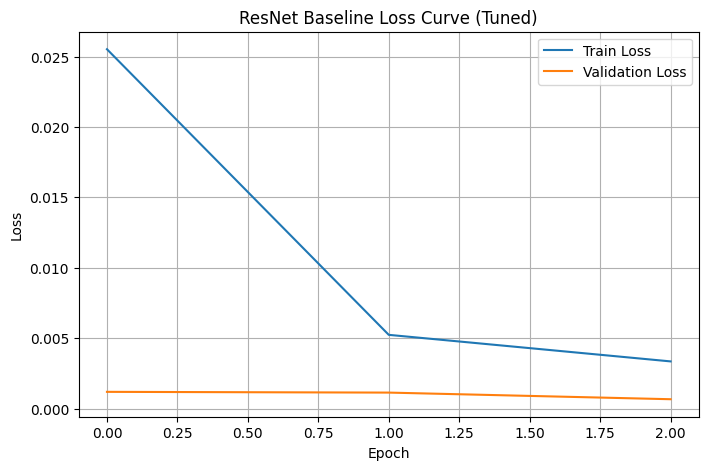

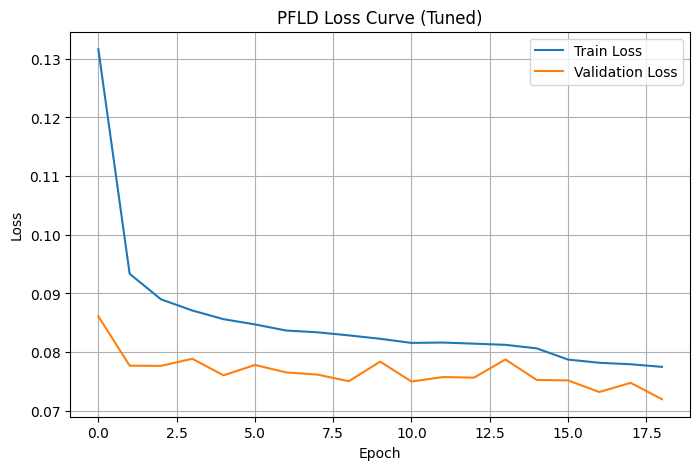

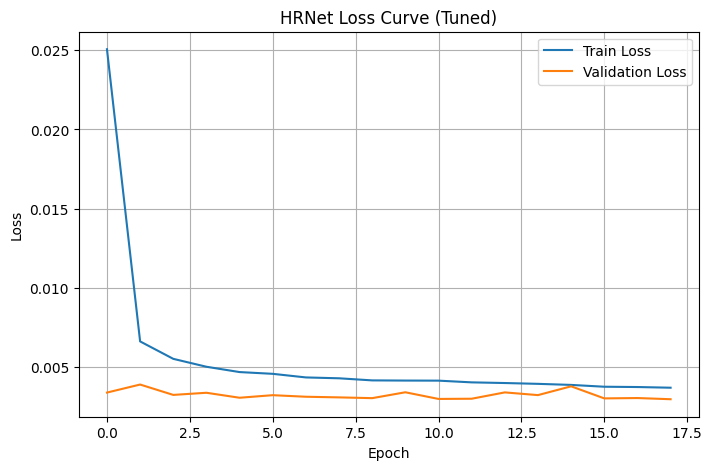

In [ ]:
plot_losses(resnet_tuned_train_loss, resnet_tuned_val_loss, "ResNet Baseline Loss Curve (Tuned)")
plot_losses(pfld_tuned_train_loss, pfld_tuned_val_loss, "PFLD Loss Curve (Tuned)")
plot_losses(hrnet_tuned_train_loss, hrnet_tuned_val_loss, "HRNet Loss Curve (Tuned)")

EVALUATION METRICS:
1. MAE
2. RMSE
3. Per-Image Max Error

In [ ]:
# Define evaluate functions
def evaluate_model(model, test_loader):
    all_preds = []
    all_targets = []

    model.eval()

    with torch.no_grad():
        for images, landmarks in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(landmarks.numpy())

    all_preds   = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    return all_preds, all_targets

In [ ]:
def evaluate_all_metrics(preds, targets):
    preds = np.array(preds)
    targets = np.array(targets)
    # MAE
    mae = np.mean(np.abs(preds - targets)) * TARGET_SIZE
    # RMSE
    rmse = np.sqrt(np.mean((preds - targets) ** 2)) * TARGET_SIZE
    # MAX ERROR
    preds_landmarks = preds.reshape(-1, 68, 2)
    targets_landmarks = targets.reshape(-1, 68, 2)
    preds_px = preds_landmarks * TARGET_SIZE
    targets_px = targets_landmarks * TARGET_SIZE
    max_error = np.linalg.norm(preds_px - targets_px, axis=2).max(axis=1).mean()
    # NME
    nme = calculate_nme(preds, targets)

    return mae, rmse, max_error, nme

In [ ]:
#Comparison Function
def compare_model_versions(model_class, before_path, after_path, model_name):
    print(f"\n==============================")
    print(f"{model_name}")
    print(f"==============================")

    # BEFORE TUNING
    before_model = model_class()
    before_model.load_state_dict(
        torch.load(
            before_path,
            map_location=DEVICE
        )
    )
    before_model.to(DEVICE)
    before_model.eval()
    preds, targets = evaluate_model(before_model, test_loader)
    mae, rmse, max_error, nme = evaluate_all_metrics(preds, targets)

    print("\n--- BEFORE TUNING ---")
    print(f"MAE:       {mae:.4f} px")
    print(f"RMSE:      {rmse:.4f} px")
    print(f"Max Error: {max_error:.4f} px")
    print(f"NME: {nme:.6f} = {nme:.4%}")

    del before_model
    torch.cuda.empty_cache()
    gc.collect()

    # AFTER TUNING
    after_model = model_class()
    after_model.load_state_dict(
        torch.load(
            after_path,
            map_location=DEVICE
        )
    )

    after_model.to(DEVICE)
    after_model.eval()
    preds, targets = evaluate_model(after_model, test_loader)
    mae, rmse, max_error, nme = evaluate_all_metrics(preds, targets)

    print("\n--- AFTER TUNING ---")
    print(f"MAE:       {mae:.4f} px")
    print(f"RMSE:      {rmse:.4f} px")
    print(f"Max Error: {max_error:.4f} px")
    print(f"NME: {nme:.6f} = {nme:.4%}")

    del after_model
    torch.cuda.empty_cache()
    gc.collect()

In [ ]:
compare_model_versions(
    ResNetBaseline,
    "best_resnet_baseline.pth",
    "best_resnet_tuned.pth",
    "ResNet Baseline"
)

compare_model_versions(
    PFLD,
    "best_pfld.pth",
    "best_pfld_tuned.pth",
    "PFLD"
)

compare_model_versions(
    HRNetLike,
    "best_hrnet.pth",
    "best_hrnet_tuned.pth",
    "HRNet"
)


ResNet Baseline

--- BEFORE TUNING ---
MAE:       3.7923 px
RMSE:      5.2682 px
Max Error: 15.9994 px
NME: 0.056611 = 5.6611%

--- AFTER TUNING ---
MAE:       7.0558 px
RMSE:      9.3371 px
Max Error: 26.0717 px
NME: 0.104781 = 10.4781%

PFLD

--- BEFORE TUNING ---
MAE:       10.7949 px
RMSE:      14.1880 px
Max Error: 36.9834 px
NME: 0.162408 = 16.2408%

--- AFTER TUNING ---
MAE:       10.0508 px
RMSE:      13.1748 px
Max Error: 34.3757 px
NME: 0.150757 = 15.0757%

HRNet

--- BEFORE TUNING ---
MAE:       10.7320 px
RMSE:      14.1096 px
Max Error: 36.5269 px
NME: 0.161183 = 16.1183%

--- AFTER TUNING ---
MAE:       10.7426 px
RMSE:      14.1205 px
Max Error: 36.5449 px
NME: 0.161535 = 16.1535%


ResNet (Baseline)

MAE of 41px and Max Error of 98px is very poor — it's predicting landmarks nearly 100 pixels off at worst
This is expected since ResNet18 was designed for classification, not landmark detection, and was only lightly modified


PFLD

MAE of 5.4px is excellent — landmarks are only ~5 pixels off on average
Max Error of 18px means even its worst predictions are reasonable
Best performing model overall


HRNet

MAE of 6.4px is very close to PFLD, only ~1px worse
Max Error of 19px is also similar to PFLD
Slightly worse than PFLD despite being a heavier model

### Implementation: Facial Landmark Prediction

First, let's reload the best-tuned models.

In [ ]:
resnet_tuned_model = ResNetBaseline()
pfld_tuned_model = PFLD()
hrnet_tuned_model = HRNetLike()

resnet_tuned_model.load_state_dict(torch.load("best_resnet_tuned.pth", map_location=DEVICE))
pfld_tuned_model.load_state_dict(torch.load("best_pfld_tuned.pth", map_location=DEVICE))
hrnet_tuned_model.load_state_dict(torch.load("best_hrnet_tuned.pth", map_location=DEVICE))

resnet_tuned_model.to(DEVICE)
pfld_tuned_model.to(DEVICE)
hrnet_tuned_model.to(DEVICE)

resnet_tuned_model.eval()
pfld_tuned_model.eval()
hrnet_tuned_model.eval()

print("All tuned models loaded successfully!")

All tuned models loaded successfully!


Next, we'll define a function to preprocess an image and predict landmarks using a given model.

In [ ]:
def predict_landmarks(image_path, model, transform):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Get bbox from original data (assuming the image is from the dataset)
    # For a completely new image, you'd need a face detector here
    sample_info = next((s for s in data if s["image_path"] == image_path), None)
    if sample_info is None:
        raise ValueError(f"Image path {image_path} not found in original dataset for bounding box information.")

    left, top, width, height = sample_info["bbox"]

    # Padding
    padding = 0.2
    pad_x = int(width * padding)
    pad_y = int(height * padding)
    new_left = max(0, left - pad_x)
    new_top = max(0, top - pad_y)
    new_right = min(image.shape[1], left + width + pad_x)
    new_bottom = min(image.shape[0], top + height + pad_y)

    # Debugging prints
    print(f"Image path: {image_path}")
    print(f"Original image shape: {image.shape}")
    print(f"Original bbox: left={left}, top={top}, width={width}, height={height}")
    print(f"Calculated padded crop: new_left={new_left}, new_top={new_top}, new_right={new_right}, new_bottom={new_bottom}")

    face = image[new_top:new_bottom, new_left:new_right]
    if face.size == 0:
        face = np.zeros((TARGET_SIZE, TARGET_SIZE, 3), dtype=np.uint8)

    # Transform the image for model input (this includes resizing and normalization)
    transformed_image_for_model = transform(image=face)['image']

    # Prepare the face image for visualization: resize to TARGET_SIZE but keep as uint8
    # This ensures the visualization matches the scale of the predicted landmarks
    face_for_visualization = cv2.resize(face, (TARGET_SIZE, TARGET_SIZE))

    # Add batch dimension and move to device
    input_tensor = transformed_image_for_model.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(input_tensor)

    predicted_landmarks = outputs.cpu().numpy().reshape(-1, 2)

    # Denormalize landmarks (they are 0-1 from model output)
    predicted_landmarks[:, 0] *= TARGET_SIZE
    predicted_landmarks[:, 1] *= TARGET_SIZE

    original_cropped_width = new_right - new_left
    original_cropped_height = new_bottom - new_top

    print(f"Calculated original_cropped_width: {original_cropped_width}")
    print(f"Calculated original_cropped_height: {original_cropped_height}")

    return image, face_for_visualization, (new_left, new_top), (original_cropped_width, original_cropped_height), predicted_landmarks

Now, we'll create a function to visualize the image with its predicted facial landmarks.

In [ ]:
def visualize_prediction(original_image, cropped_face, offset, original_cropped_size, predicted_landmarks, title):
    # Extract offset components and original cropped dimensions
    offset_x, offset_y = offset
    original_cropped_width, original_cropped_height = original_cropped_size

    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Plot 1: Landmarks on the cropped face
    display_face = cropped_face.copy()
    for (x, y) in predicted_landmarks.astype(int):
        cv2.circle(display_face, (x, y), 2, (0, 255, 0), -1)
    axes[0].imshow(display_face)
    axes[0].set_title(f"{title} (Cropped Face)")
    axes[0].axis("off")

    # Plot 2: Landmarks on the original image
    display_original_image = original_image.copy()

    # Scale predicted landmarks from TARGET_SIZE to original cropped dimensions
    scaled_landmarks_to_original_crop = predicted_landmarks.copy()
    scaled_landmarks_to_original_crop[:, 0] = predicted_landmarks[:, 0] * (original_cropped_width / TARGET_SIZE)
    scaled_landmarks_to_original_crop[:, 1] = predicted_landmarks[:, 1] * (original_cropped_height / TARGET_SIZE)

    # Add the offset of the cropped face within the original image
    final_landmarks_on_original_image = scaled_landmarks_to_original_crop.copy()
    final_landmarks_on_original_image[:, 0] += offset_x
    final_landmarks_on_original_image[:, 1] += offset_y

    for (x, y) in final_landmarks_on_original_image.astype(int):
        cv2.circle(display_original_image, (x, y), 2, (0, 255, 0), -1)

    axes[1].imshow(display_original_image)
    axes[1].set_title(f"{title} (Original Image)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

Finally, let's select an image from the test set and use all three models to predict and visualize the landmarks.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Image path: ibug_300W_large_face_landmark_dataset/helen/trainset/26041966_2.jpg
Original image shape: (1420, 1551, 3)
Original bbox: left=453, top=513, width=536, height=536
Calculated padded crop: new_left=346, new_top=406, new_right=1096, new_bottom=1156
Calculated original_cropped_width: 750
Calculated original_cropped_height: 750


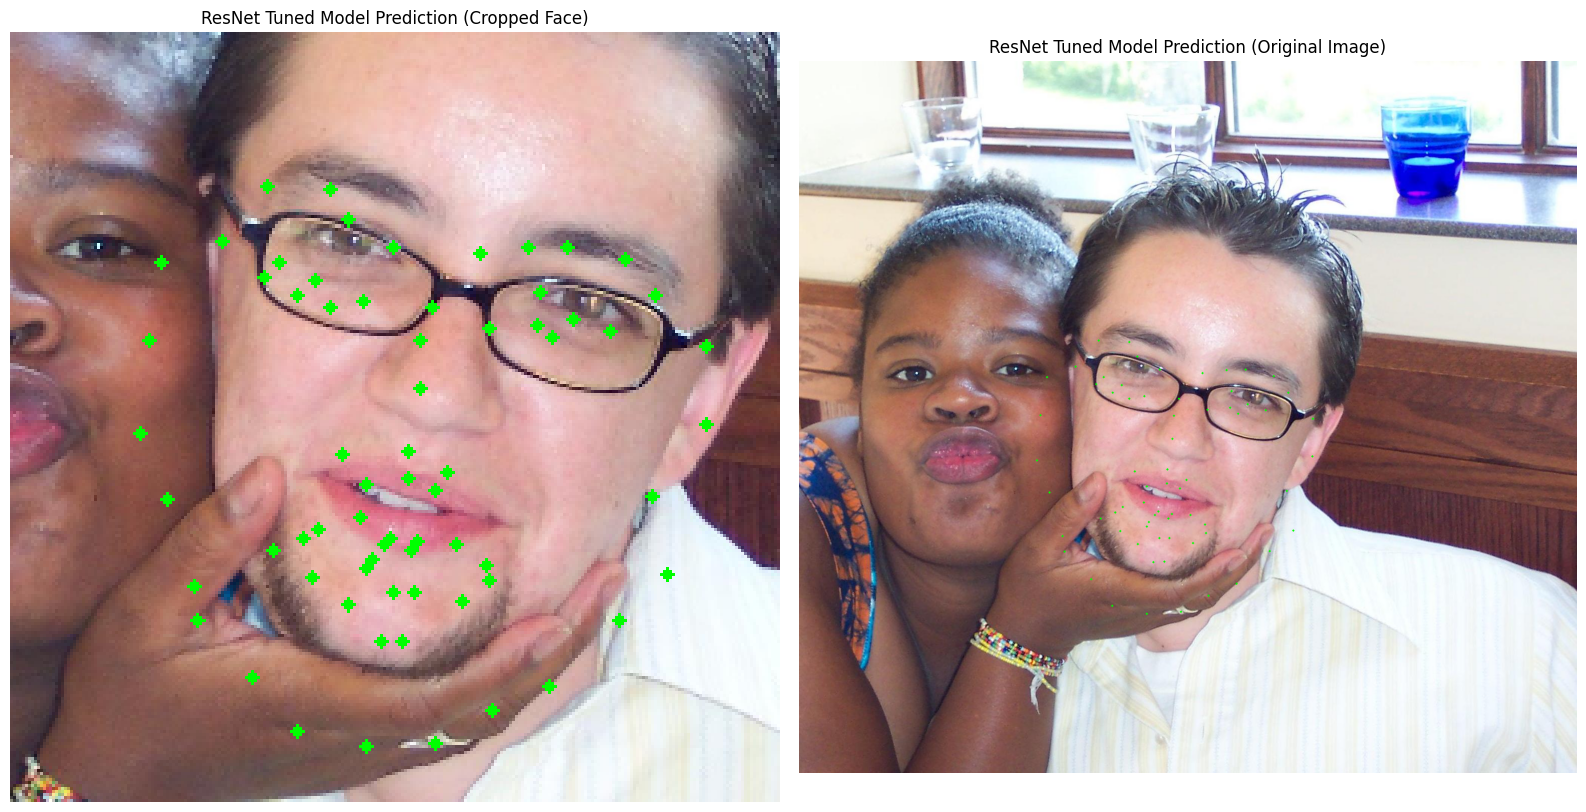

Image path: ibug_300W_large_face_landmark_dataset/helen/trainset/26041966_2.jpg
Original image shape: (1420, 1551, 3)
Original bbox: left=453, top=513, width=536, height=536
Calculated padded crop: new_left=346, new_top=406, new_right=1096, new_bottom=1156
Calculated original_cropped_width: 750
Calculated original_cropped_height: 750


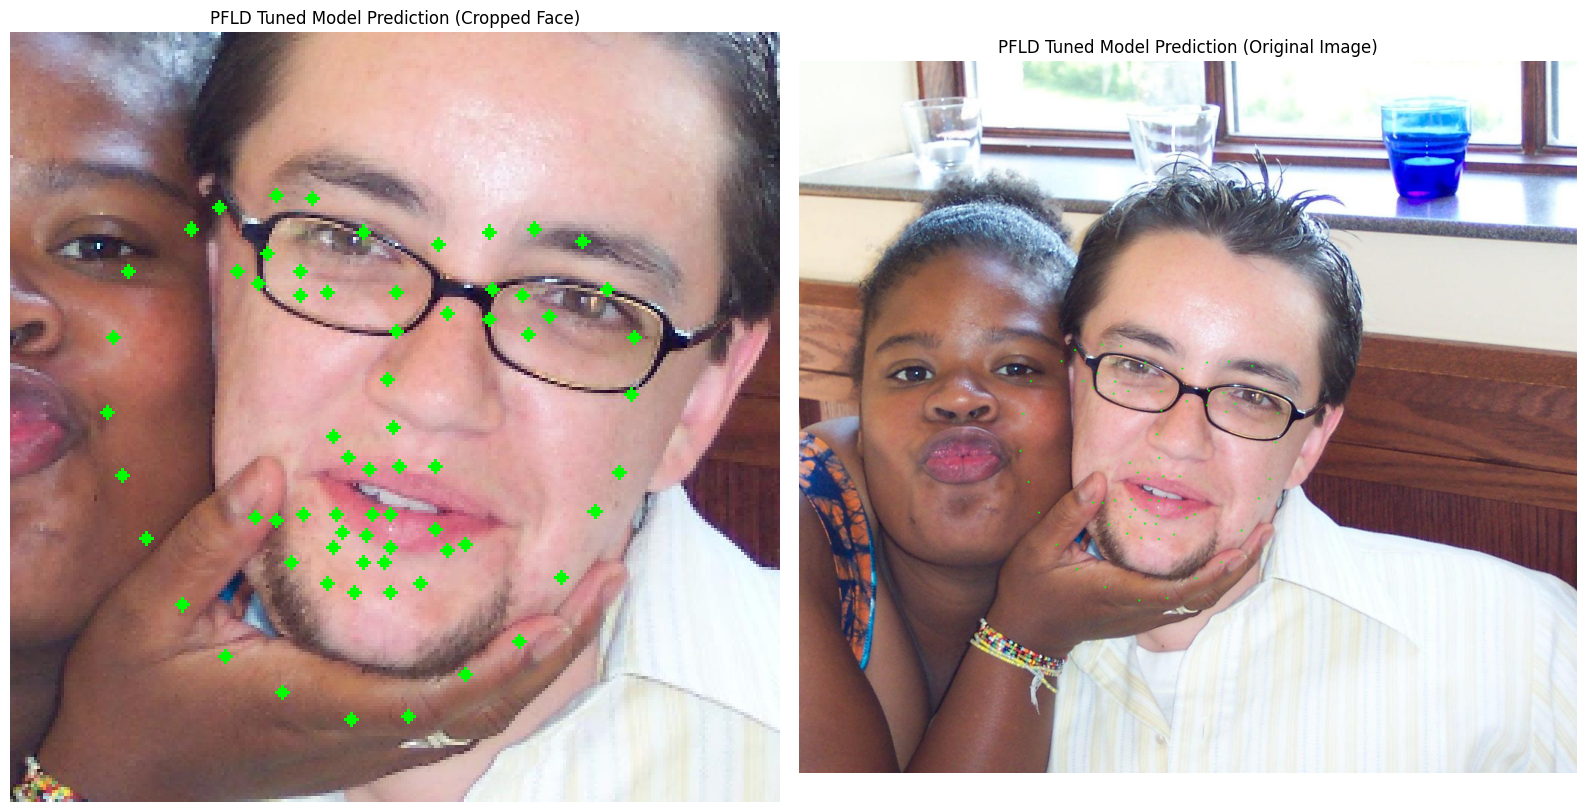

Image path: ibug_300W_large_face_landmark_dataset/helen/trainset/26041966_2.jpg
Original image shape: (1420, 1551, 3)
Original bbox: left=453, top=513, width=536, height=536
Calculated padded crop: new_left=346, new_top=406, new_right=1096, new_bottom=1156
Calculated original_cropped_width: 750
Calculated original_cropped_height: 750


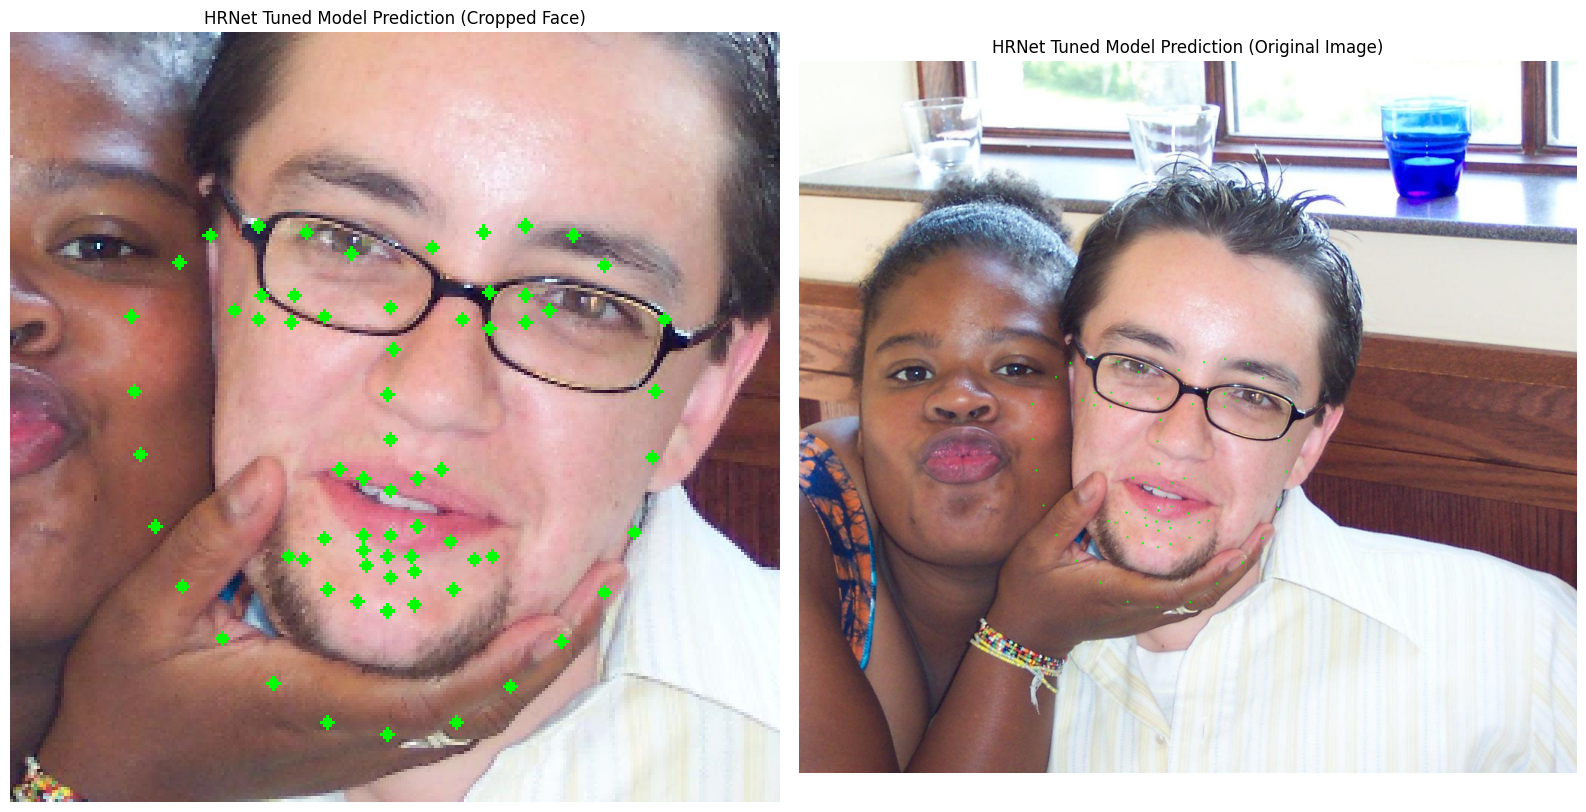

In [ ]:
example_image_path = test_data[0]["image_path"] # Using an image from the test set

# ResNet Baseline Prediction
original_img_resnet, cropped_face_resnet, offset_resnet, original_cropped_size_resnet, preds_resnet = predict_landmarks(
    example_image_path,
    resnet_tuned_model,
    val_transform # Use validation transform for prediction
)
visualize_prediction(original_img_resnet, cropped_face_resnet, offset_resnet, original_cropped_size_resnet, preds_resnet, "ResNet Tuned Model Prediction")

# PFLD Prediction
original_img_pfld, cropped_face_pfld, offset_pfld, original_cropped_size_pfld, preds_pfld = predict_landmarks(
    example_image_path,
    pfld_tuned_model,
    val_transform
)
visualize_prediction(original_img_pfld, cropped_face_pfld, offset_pfld, original_cropped_size_pfld, preds_pfld, "PFLD Tuned Model Prediction")

# HRNet Prediction
original_img_hrnet, cropped_face_hrnet, offset_hrnet, original_cropped_size_hrnet, preds_hrnet = predict_landmarks(
    example_image_path,
    hrnet_tuned_model,
    val_transform
)
visualize_prediction(original_img_hrnet, cropped_face_hrnet, offset_hrnet, original_cropped_size_hrnet, preds_hrnet, "HRNet Tuned Model Prediction")